In [ ]:
import pandas as pd
import numpy as np
import scipy.optimize as opt
import matplotlib.pyplot as plt
import statsmodels.api as sm
import QuantLib as ql

In [ ]:
# Create the table 
data = {
    'Col0': [1, 3, 5, 7, 9, 11],
    'Col1': [2, 4, 6, 8, 10, 12]
}
row_names = ['Idx0', 'Idx1', 'Idx2', 'Idx3', 'Idx4', 'Idx5']

table = pd.DataFrame(data, index=row_names)
print("Original table:")
print(table)

# First modification: row 3, column 1 (zero-based)
old_value_1 = table.iloc[3, 1]
table.iloc[3, 1] = old_value_1 + 1

# Second modification: intersection between "Idx0" and "Col1"
old_value_2 = table.loc['Idx0', 'Col1']
table.loc['Idx0', 'Col1'] = old_value_2 + 2

print("\nFinal modified table:")
print(table)

Original table:
      Col0  Col1
Idx0     1     2
Idx1     3     4
Idx2     5     6
Idx3     7     8
Idx4     9    10
Idx5    11    12

Final modified table:
      Col0  Col1
Idx0     1     4
Idx1     3     4
Idx2     5     6
Idx3     7     9
Idx4     9    10
Idx5    11    12


In [35]:
x = 0.4

# Numerator 
numerator = x * np.sinh(x)

# Denominator 
exponent = (x ** 2) / 2
denominator = 1 + np.exp(exponent)

# Result
division = numerator / denominator
result = np.log(division)

print("The result of the calculation is:", result)

The result of the calculation is: -2.5400025589406656


In [37]:
mu = 1

def compute_formula(x):
    exponent = -((x - mu) ** 2) / 2  # We added a minus sign to make the problem well-defined
    result = -x * np.exp(exponent)
    # Return the result with a MINUS sign in order to find the maximum
    return result 

# Optimization
optimization = opt.minimize_scalar(compute_formula)

x_point = optimization.x
# Restore the minus sign to get the positive maximum value
maximum_value = -optimization.fun 

print("The maximum point is at x =", x_point)
print("The maximum value is =", maximum_value)

The maximum point is at x = 1.6180339988009027
The maximum value is = 1.336733323596827


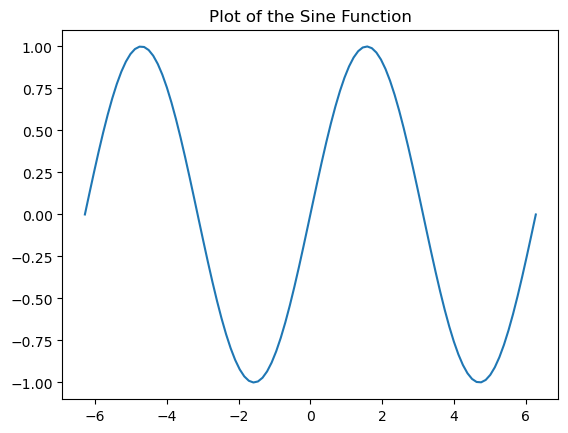

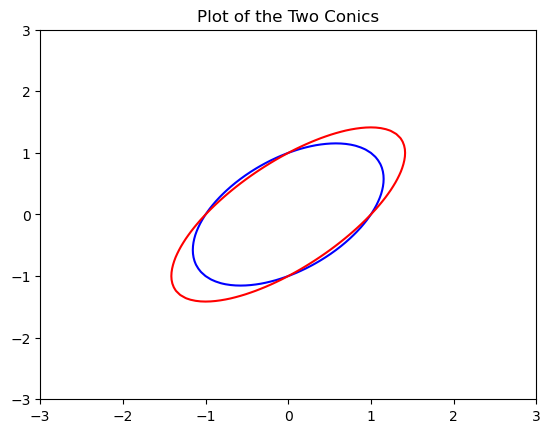

In [39]:
# Sine function
# Create 100 numbers ranging from -2pi to +2pi
x_values = np.linspace(-2 * np.pi, 2 * np.pi, 100)
y_values = np.sin(x_values)

plt.figure()  # Create a new blank figure
plt.plot(x_values, y_values)
plt.title("Plot of the Sine Function")
plt.show()  # Display the figure

# Conics
# grid of points
x_grid = np.linspace(-3, 3, 100)
y_grid = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_grid, y_grid)

rho_1 = 1 / 2
rho_2 = 1 / np.sqrt(2)

# Write the two equations
formula_1 = (X ** 2) - (2 * rho_1 * X * Y) + (Y ** 2)
formula_2 = (X ** 2) - (2 * rho_2 * X * Y) + (Y ** 2)

plt.figure()
# The 'contour' command draws only the lines where the formula is exactly equal to 1
plt.contour(X, Y, formula_1, levels=[1], colors='blue')
plt.contour(X, Y, formula_2, levels=[1], colors='red')
plt.title("Plot of the Two Conics")
plt.show()  # Display the figure


In [41]:
# Take only the first 5 rows of the table created in Point A
first_5_rows = table.head(5)

# Prepare the data: Column 0 is X, Column 1 is Y
X = first_5_rows['Col0']
Y = first_5_rows['Col1']

# fixed rule of this library: we must add a "constant"
X_ready = sm.add_constant(X)

# Create the linear model and fit it
model = sm.OLS(Y, X_ready)
results = model.fit()

print("The estimated parameters are:")
print(results.params)

The estimated parameters are:
const    2.35
Col0     0.85
dtype: float64


In [43]:
# Year fraction
start_date = ql.Date(19, 2, 2008)
end_date = ql.Date(19, 5, 2008)

# European rule
day_count_rule = ql.Thirty360(ql.Thirty360.European)
year_fraction = day_count_rule.yearFraction(start_date, end_date)

print("Calculated year fraction:", year_fraction)

# Calendar
start_date_calendar = ql.Date(31, 10, 2025)
calendar = ql.TARGET()

print("\nDates for the next 6 months (Modified Following):")
# Use a simple loop to print the next 6 months
for month_number in range(7):
    # 'advance' simply moves the date forward by a given number of months
    new_date = calendar.advance(
        start_date_calendar,
        month_number,
        ql.Months,
        ql.ModifiedFollowing
    )
    print("Month", month_number, "->", new_date)

Calculated year fraction: 0.25

Dates for the next 6 months (Modified Following):
Month 0 -> October 31st, 2025
Month 1 -> November 28th, 2025
Month 2 -> December 31st, 2025
Month 3 -> January 30th, 2026
Month 4 -> February 27th, 2026
Month 5 -> March 31st, 2026
Month 6 -> April 30th, 2026
